# Classification Masks Test and Visualization

This notebook loads classification data from a JSON file and visualizes the segmentation masks associated with each annotation. It compares:
- **Composite Masks**: Combined masks from all brush modifications and SAM interactions
- **SAM Masks**: The latest segmentation mask generated by SAM (Segment Anything Model)

## Purpose
- Verify that masks are being correctly saved and encoded
- Inspect the relationship between SAM-generated masks and brush-modified composite masks
- Validate mask dimensions and decoding process

In [82]:
# Import required libraries for data handling, visualization, and mask decoding
import json  # for loading JSON classification data
import getpass
import urllib
import PIL
from MaskDecoder import MaskDecoder  # custom decoder for RLE-encoded masks
import matplotlib.pyplot as plt  # for creating plots and figures
from matplotlib.pyplot import colormaps  # for accessing colormap functions
import matplotlib.patches as mpatches  # for creating custom legend patches
import numpy as np  # for numerical operations and array handling
from panoptes_client import Panoptes, Subject

from segment_anything import SamPredictor, sam_model_registry
from huggingface_hub import hf_hub_download
import torch

In [83]:
class SamMaskPredictor:
    """Predict binary segmentation masks from labeled point prompts.

    Supports both SAM1 model IDs (`sam1-vit_b`, `sam1-vit_l`, `sam1-vit_h`)
    and SAM2 model IDs (e.g. `sam2-hiera-large`). Predictors are cached
    by model ID to avoid reloading checkpoints between calls.
    """

    def __init__(self, model_id: str):
        self._predictors = {}
        self.model_id = model_id
        self.predictor = self._get_predictor(model_id=self.model_id)
        self.image = None

    def _get_predictor(self, model_id: str):
        if model_id not in self._predictors:
            if model_id.startswith("sam1-"):
                try:
                    vit_type = model_id.replace("sam1-", "")
                    if vit_type not in ("vit_b", "vit_l", "vit_h"):
                        vit_type = "vit_h"

                    ckpt_map = {
                        "vit_b": (
                            "ybelkada/segment-anything",
                            "checkpoints/sam_vit_b_01ec64.pth",
                        ),
                        "vit_l": (
                            "ybelkada/segment-anything",
                            "checkpoints/sam_vit_l_0b3195.pth",
                        ),
                        "vit_h": (
                            "ybelkada/segment-anything",
                            "checkpoints/sam_vit_h_4b8939.pth",
                        ),
                    }
                    repo_id, filename = ckpt_map[vit_type]
                    ckpt_path = hf_hub_download(repo_id=repo_id, filename=filename)
                    sam = sam_model_registry[vit_type](checkpoint=ckpt_path)
                    sam.to(
                        device=(
                            "cuda"
                            if torch.cuda.is_available()
                            else "mps" if torch.mps.is_available() else "cpu"
                        )
                    )
                    self._predictors[model_id] = ("sam1", SamPredictor(sam))
                except ImportError as e:
                    raise RuntimeError(
                        "SAM1 requires segment-anything. Install with: "
                        "pip install git+https://github.com/facebookresearch/segment-anything.git"
                    ) from e
            else:
                try:
                    from sam2.sam2_image_predictor import SAM2ImagePredictor

                    hf_id = f"facebook/{model_id}"
                    self._predictors[model_id] = (
                        "sam2",
                        SAM2ImagePredictor.from_pretrained(hf_id),
                    )
                except ImportError as e:
                    if "huggingface_hub" in str(e):
                        raise RuntimeError(
                            "huggingface_hub not installed. Run: pip install huggingface_hub"
                        ) from e
                    raise RuntimeError(
                        "SAM2 not installed. Clone https://github.com/facebookresearch/sam2 "
                        "and run: pip install -e ./sam2"
                    ) from e

        return self._predictors[model_id]
    
    def set_image(self, image: np.ndarray):
        self.image = image
    
    def set_predictor_image(self, image: np.ndarray | None = None):
        if image is not None:
            self.set_image(image)
        self.predictor[1].set_image(self.image)

    def predict_mask(
        self,
        labeled_points: list[dict[str, float | int] | tuple[float, float, int]],
        image: np.ndarray | None = None,
        model_id: str | None = None,

    ):
        """Return a predicted binary mask for a single image.

        Args:
            model_id: SAM model identifier (SAM1 or SAM2).
            labeled_points: Iterable of point prompts, where each item is either:
                - dict with keys {"x", "y", "label"}
                - tuple/list in form (x, y, label)

        Returns:
            np.ndarray mask with shape (H, W), dtype uint8, values in {0, 1}.
        """

        if labeled_points is None or len(labeled_points) == 0:
            raise ValueError("labeled_points must contain at least one point")

        coords = []
        labels = []
        for p in labeled_points:
            if isinstance(p, dict):
                coords.append([float(p["x"]), float(p["y"])])
                labels.append(int(p["label"]))
            else:
                x, y, label = p
                coords.append([float(x), float(y)])
                labels.append(int(label))

        point_coords = np.asarray(coords, dtype=np.float32)
        point_labels = np.asarray(labels, dtype=np.int32)

        # if we need a different model
        if model_id is not None:
            self.predictor = self._get_predictor(model_id)
            # if the model is new, we need to set the image
            # if image is None, the cached image will be used.
            self.set_predictor_image(image)
        
        backend, predictor = self.predictor

        if backend == "sam1":
            masks, _, _ = predictor.predict(
                point_coords=point_coords,
                point_labels=point_labels,
                multimask_output=False,
            )
        else:
            masks, _, _ = predictor.predict(
                point_coords=point_coords,
                point_labels=point_labels,
                multimask_output=False,
            )

        # Standardize output to a single binary uint8 mask.
        mask = masks[0] if masks.ndim == 3 else masks
        return (mask > 0).astype(np.uint8)

In [84]:
class MaskCutoutHelper:
    """Utility for mask bounds, cutout creation, and inset rendering.

    Uses astropy.nddata.Cutout2D when available, with NumPy slicing fallback.
    """

    def __init__(self, pad_frac: float = 0.10):
        self.pad_frac = pad_frac
        try:
            from astropy.nddata import Cutout2D

            self._Cutout2D = Cutout2D
        except Exception:
            self._Cutout2D = None

    @staticmethod
    def get_mask_bounds(mask_array: np.ndarray):
        non_zero = np.nonzero(mask_array)
        if len(non_zero[0]) == 0:
            return None
        y_min, y_max = int(non_zero[0].min()), int(non_zero[0].max())
        x_min, x_max = int(non_zero[1].min()), int(non_zero[1].max())
        return (y_min, y_max, x_min, x_max)

    @staticmethod
    def get_non_overlapping_inset_location(
        image_height: int,
        image_width: int,
        masked_y_min: int,
        masked_y_max: int,
        masked_x_min: int,
        masked_x_max: int,
    ):
        masked_y_center = (masked_y_min + masked_y_max) / 2
        masked_x_center = (masked_x_min + masked_x_max) / 2

        if masked_y_center < image_height / 2:
            return "lower right" if masked_x_center < image_width / 2 else "lower left"
        return "upper right" if masked_x_center < image_width / 2 else "upper left"

    def build_bbox(self, mask_array: np.ndarray):
        bounds = self.get_mask_bounds(mask_array)
        if bounds is None:
            return None

        y_min, y_max, x_min, x_max = bounds
        y_pad = max(1, int(self.pad_frac * max(1, y_max - y_min)))
        x_pad = max(1, int(self.pad_frac * max(1, x_max - x_min)))

        h, w = mask_array.shape[:2]
        y0 = max(0, y_min - y_pad)
        y1 = min(h, y_max + y_pad + 1)
        x0 = max(0, x_min - x_pad)
        x1 = min(w, x_max + x_pad + 1)
        return (y0, y1, x0, x1)

    def make_cutout(self, array: np.ndarray, bbox):
        y0, y1, x0, x1 = bbox
        if self._Cutout2D is None:
            return array[y0:y1, x0:x1]

        center = ((x0 + x1 - 1) / 2, (y0 + y1 - 1) / 2)
        size = (max(1, y1 - y0), max(1, x1 - x0))
        cut = self._Cutout2D(array, position=center, size=size, mode="trim")
        return cut.data


plot_helper = MaskCutoutHelper(pad_frac=0.12)

## Load Test Classification Data

The test classification file contains exported annotations from a Caesar reduction task. Each annotation includes optional mask data:
- `annotationId`: Unique identifier for the annotation (e.g., "-1" for whole image, or rect coordinates)
- `latestSamMask`: The SAM segmentation mask (RLE-encoded)
- `compositeMask`: The composite mask after all brush modifications (RLE-encoded)

Both mask formats include width, height, RLE data, and encoding metadata.

In [85]:
TEST_CLASSIFICATION_PATH = "test_classification.json"

with open(TEST_CLASSIFICATION_PATH, "r") as classification_file:
    data = json.load(classification_file)

## Load subject image from Panoptes

In [86]:
username = input("Enter Panoptes username:")
password = getpass.getpass("Enter Panoptes password")

In [87]:
pan = Panoptes.connect(username=username, password=password)

In [88]:
subject_id = data["links"]["subjects"][0]
subject = Subject.find(subject_id)
for k, v in next(iter(subject.locations)).items():
    subject_image = PIL.Image.open(urllib.request.urlopen(v))
    subject_data = np.array(subject_image)

## Load SAM point histories for rects

In [89]:
sam_point_histories = [
    anno["samPointHistory"] for anno in data["annotations"][0]["value"]
]

In [90]:
sam_model_id = data["annotations"][0]["value"][0]["samModelId"]

## Reconstruct SAM history

In [91]:
smp = SamMaskPredictor(sam_model_id)
smp.set_predictor_image(image=np.array(subject_image.convert("RGB")))

No SAM points at history index 0
No SAM points at history index 1
Rect 0 History index 2 [{'x': 1498.508329432436, 'y': 213.38908782363896, 'label': 1}]
Rect 0 History index 3 [{'x': 1458.4055296911213, 'y': 115.2441418163909, 'label': 1}]


/var/folders/ff/6x49lsb142z6xcfbp_382_zxsrvmj6/T/ipykernel_70065/2475343919.py:207: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


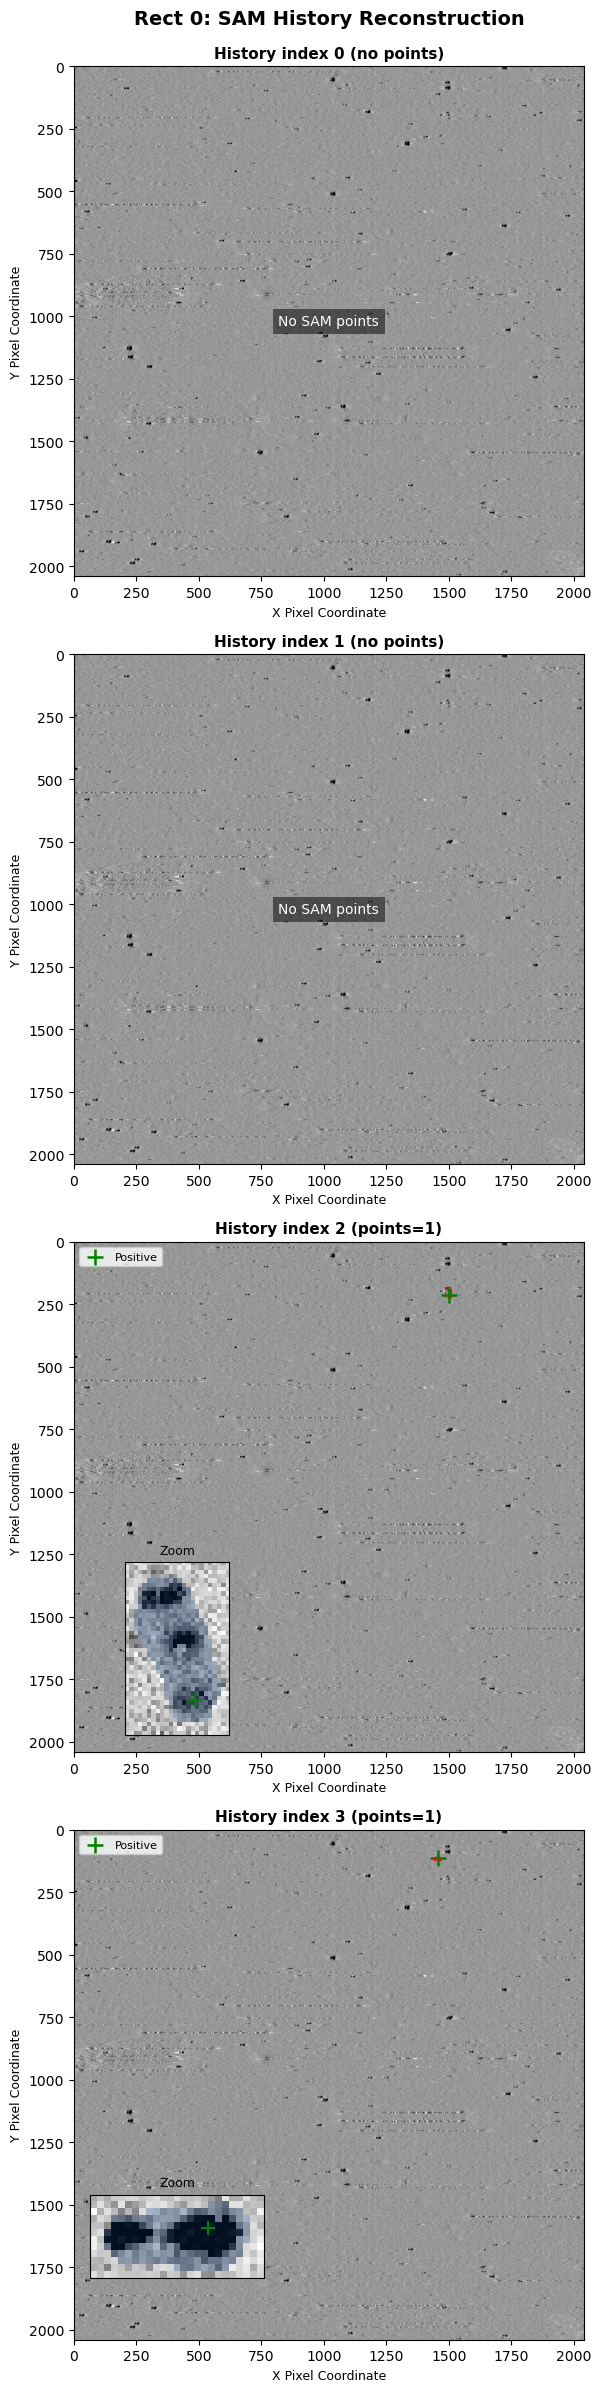

Rect 1 History index 0 [{'x': 1591.5279683584624, 'y': 890.274554018906, 'label': 1}]
Rect 1 History index 1 [{'x': 1625.3629641761916, 'y': 916.2661807748316, 'label': 1}]
Rect 1 History index 2 [{'x': 1625.3629641761916, 'y': 916.2661807748316, 'label': 1}]
Rect 1 History index 3 [{'x': 1625.3629641761916, 'y': 916.2661807748316, 'label': 1}]


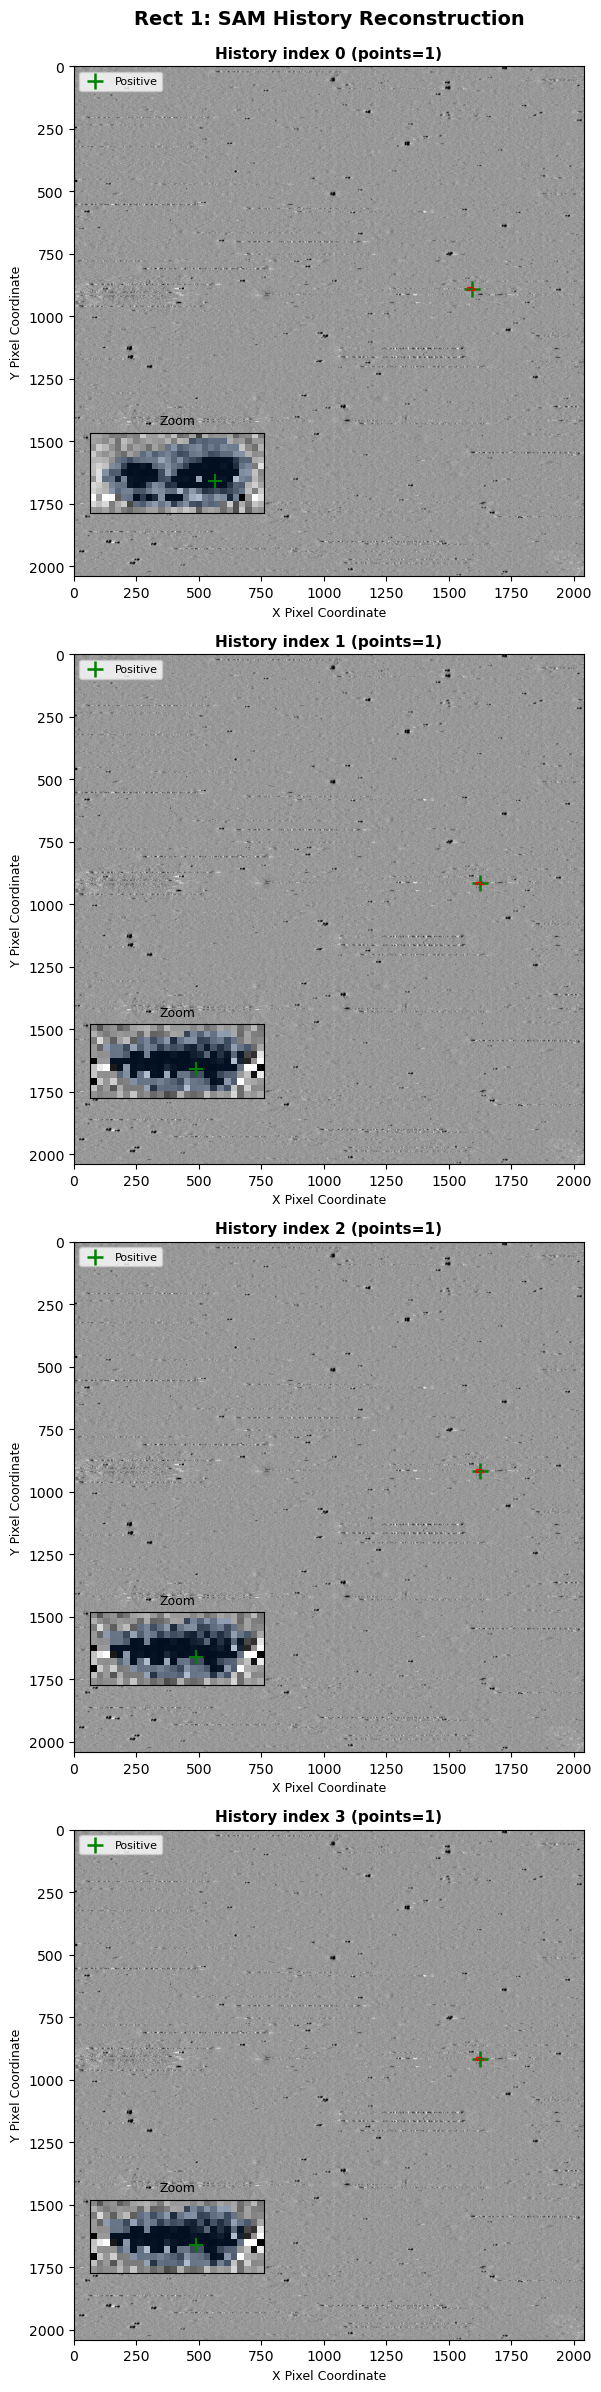

Rect 2 History index 0 [{'x': 434.1138716427882, 'y': 892.0851978338528, 'label': 1}]
Rect 2 History index 1 [{'x': 421.02956792132443, 'y': 947.8386288998591, 'label': 1}]
Rect 2 History index 2 [{'x': 421.02956792132443, 'y': 947.8386288998591, 'label': 1}]


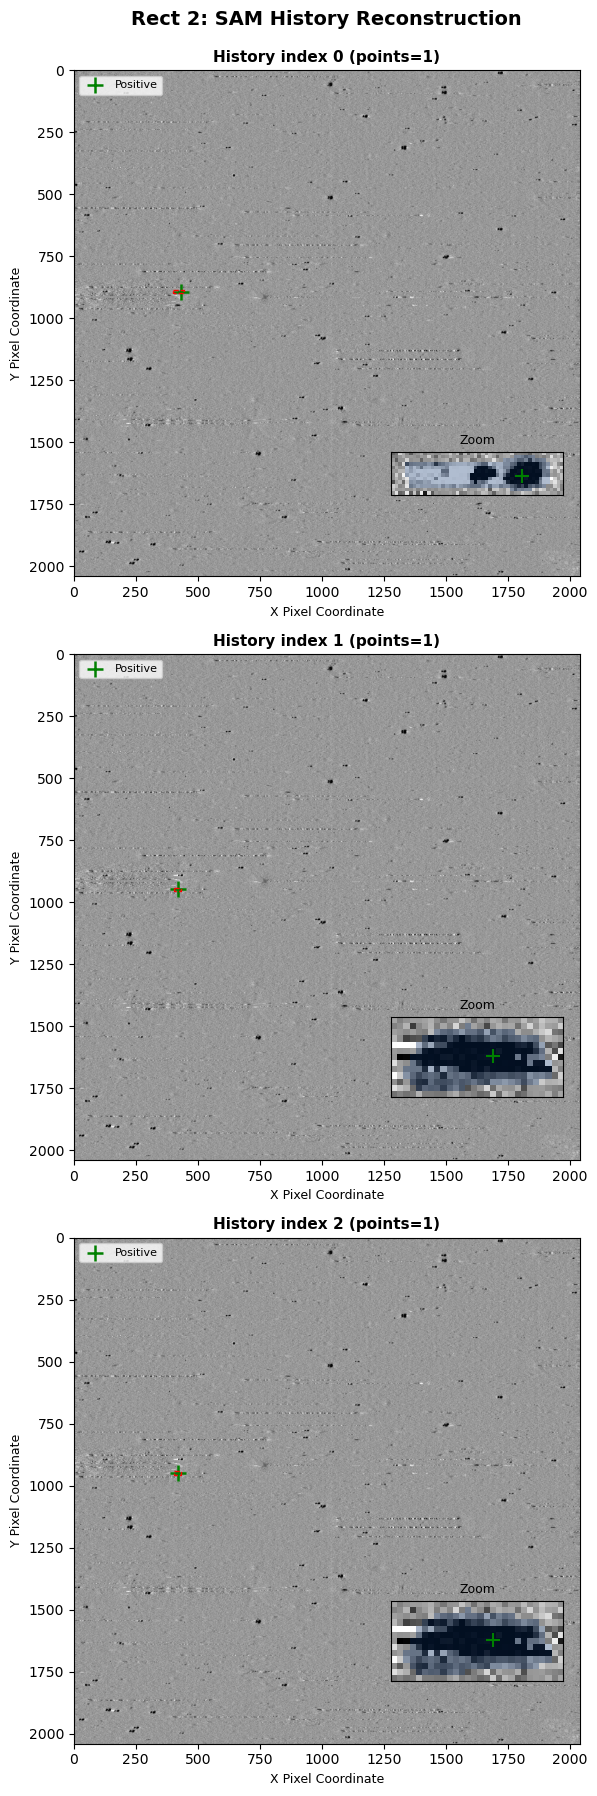

In [92]:
from math import ceil
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.patches import Rectangle

for i_rect, sam_point_history in enumerate(sam_point_histories):
    history_entries = sam_point_history["activePointsPerHistoryIndex"]
    n_hist = len(history_entries)

    if n_hist == 0:
        print(f"Rect {i_rect}: no history entries")
        continue

    # One subplot per history index in a single column.
    ncols = 1
    nrows = n_hist

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(8, 6 * nrows),
        squeeze=False,
    )
    axes_flat = axes.ravel()

    fig.suptitle(
        f"Rect {i_rect}: SAM History Reconstruction",
        fontsize=14,
        fontweight="bold",
        y=0.995,
    )

    for i_hist, active_points in enumerate(history_entries):
        ax = axes_flat[i_hist]

        ax.imshow(subject_data, cmap="Greys")
        ax.set_xlim(0, subject_data.shape[1])
        ax.set_ylim(subject_data.shape[0], 0)

        points = [
            sam_point_history["allSamPoints"][active_point]
            for active_point in active_points
        ]

        if len(points):
            print(f"Rect {i_rect}", f"History index {i_hist}", points)

            xs = [
                sam_point_history["allSamPoints"][active_point]["x"]
                for active_point in active_points
            ]
            ys = [
                sam_point_history["allSamPoints"][active_point]["y"]
                for active_point in active_points
            ]
            labels = [
                sam_point_history["allSamPoints"][active_point]["label"]
                for active_point in active_points
            ]

            x_pos = [x for x, lbl in zip(xs, labels) if lbl == 1]
            y_pos = [y for y, lbl in zip(ys, labels) if lbl == 1]
            x_neg = [x for x, lbl in zip(xs, labels) if lbl == 0]
            y_neg = [y for y, lbl in zip(ys, labels) if lbl == 0]

            if x_pos and y_pos:
                ax.scatter(
                    x_pos,
                    y_pos,
                    c="g",
                    marker="+",
                    s=140,
                    linewidths=1.8,
                    label="Positive",
                )

            if x_neg and y_neg:
                ax.scatter(
                    x_neg,
                    y_neg,
                    facecolors="none",
                    edgecolors="r",
                    marker="o",
                    s=95,
                    linewidths=1.5,
                    label="Negative",
                )

            mask = smp.predict_mask(points)
            ax.imshow(
                mask,
                cmap="Blues",
                alpha=np.where(mask > 0, 0.25, 0),
                interpolation="nearest",
            )

            # Inset zoom for this history plot
            bbox = plot_helper.build_bbox(mask.astype(np.uint8))
            if bbox is not None:
                y0, y1, x0, x1 = bbox

                inset_location = plot_helper.get_non_overlapping_inset_location(
                    subject_data.shape[0],
                    subject_data.shape[1],
                    y0,
                    y1,
                    x0,
                    x1,
                )

                axins = inset_axes(
                    ax,
                    width="34%",
                    height="34%",
                    loc=inset_location,
                    borderpad=1.2,
                )

                base_cutout = plot_helper.make_cutout(subject_data, bbox)
                axins.imshow(base_cutout, cmap="Greys", interpolation="nearest")

                mask_cutout = plot_helper.make_cutout(mask, bbox)
                axins.imshow(
                    mask_cutout,
                    cmap="Blues",
                    alpha=np.where(mask_cutout > 0, 0.32, 0),
                    interpolation="nearest",
                )

                zoom_points = [
                    (x - x0, y - y0, lbl)
                    for x, y, lbl in zip(xs, ys, labels)
                    if x0 <= x < x1 and y0 <= y < y1
                ]

                x_pos_zoom = [x for x, y, lbl in zoom_points if lbl == 1]
                y_pos_zoom = [y for x, y, lbl in zoom_points if lbl == 1]
                x_neg_zoom = [x for x, y, lbl in zoom_points if lbl == 0]
                y_neg_zoom = [y for x, y, lbl in zoom_points if lbl == 0]

                if x_pos_zoom and y_pos_zoom:
                    axins.scatter(
                        x_pos_zoom,
                        y_pos_zoom,
                        c="g",
                        marker="+",
                        s=100,
                        linewidths=1.5,
                    )

                if x_neg_zoom and y_neg_zoom:
                    axins.scatter(
                        x_neg_zoom,
                        y_neg_zoom,
                        facecolors="none",
                        edgecolors="r",
                        marker="o",
                        s=75,
                        linewidths=1.3,
                    )

                # show inset region on main axes
                rect = Rectangle(
                    (x0, y0),
                    x1 - x0,
                    y1 - y0,
                    linewidth=1.0,
                    edgecolor="red",
                    facecolor="none",
                    linestyle="--",
                )
                ax.add_patch(rect)

                axins.set_xticks([])
                axins.set_yticks([])
                axins.set_title("Zoom", fontsize=9)

            ax.set_title(
                f"History index {i_hist} (points={len(points)})",
                fontsize=11,
                fontweight="bold",
            )
            ax.legend(loc="upper left", fontsize=8)

        else:
            print(f"No SAM points at history index {i_hist}")
            ax.set_title(
                f"History index {i_hist} (no points)",
                fontsize=11,
                fontweight="bold",
            )
            ax.text(
                0.5,
                0.5,
                "No SAM points",
                transform=ax.transAxes,
                ha="center",
                va="center",
                fontsize=10,
                color="white",
                bbox=dict(facecolor="black", alpha=0.5, edgecolor="none"),
            )

        ax.set_xlabel("X Pixel Coordinate", fontsize=9)
        ax.set_ylabel("Y Pixel Coordinate", fontsize=9)
        ax.grid(True, alpha=0.2, linestyle=":", linewidth=0.5)

    plt.tight_layout()
    plt.show()

## Visualize Masks with Inset Zoom

For each annotation that has mask data, we create a visualization showing:
- The full image with overlay masks at different opacities
  - **Composite Mask** (gray, alpha=0.5): Shows all brush modifications combined
  - **SAM Mask** (blue, alpha=0.6): Shows the latest SAM segmentation
- An **inset axes** that zooms into the region containing the mask, positioned intelligently to avoid overlapping the masked data itself

The inset is automatically positioned in the opposite quadrant from the masked region, ensuring clear visibility without obstruction.

/var/folders/ff/6x49lsb142z6xcfbp_382_zxsrvmj6/T/ipykernel_70065/3285737374.py:150: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


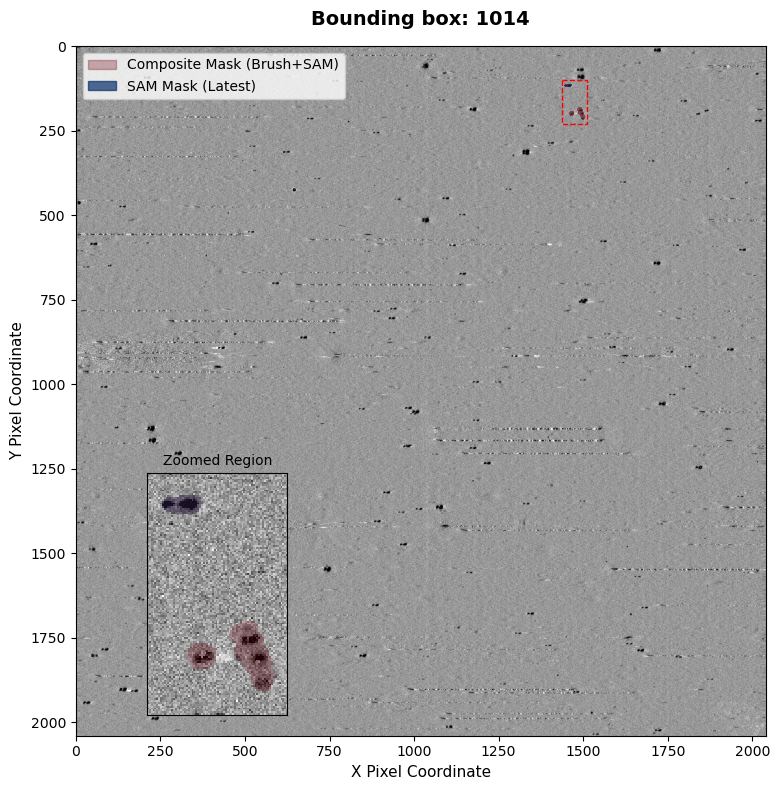

✓ Bounding box 1014:
  - Composite: 2040×2040 (gzip-base64)
  - SAM: 2040×2040 (gzip-base64)



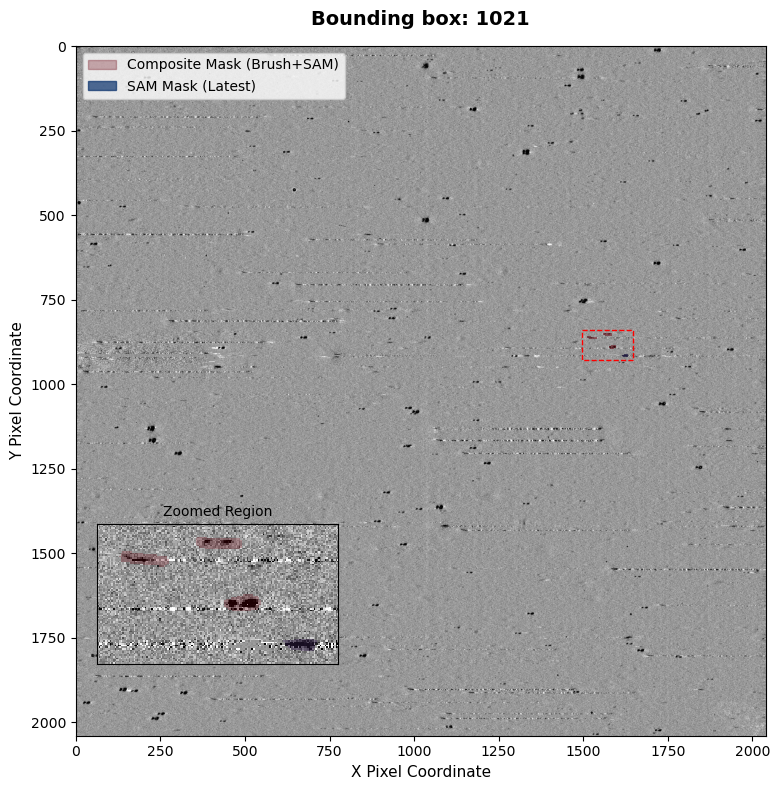

✓ Bounding box 1021:
  - Composite: 2040×2040 (gzip-base64)
  - SAM: 2040×2040 (gzip-base64)



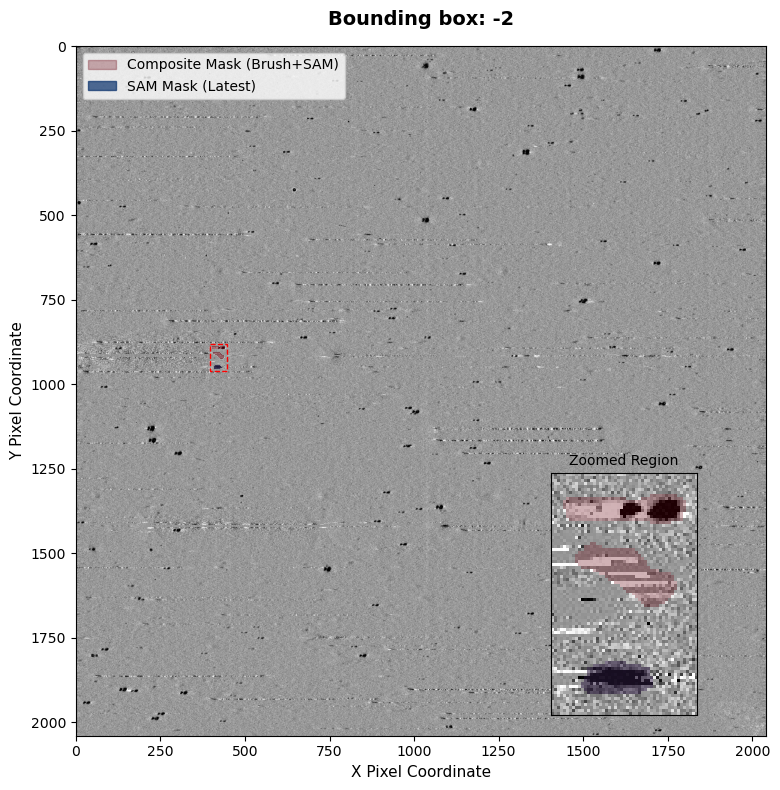

✓ Bounding box -2:
  - Composite: 2040×2040 (gzip-base64)
  - SAM: 2040×2040 (gzip-base64)



In [93]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.patches import Rectangle

if "plot_helper" not in globals():
    raise RuntimeError(
        "plot_helper is not defined. Run Cell 15 (MaskCutoutHelper setup) first."
    )

# Iterate through all annotations in the first task
for annotation_value in data["annotations"][0]["value"]:
    # Only visualize annotations that have mask data
    if "latestSamMask" in annotation_value or "compositeMask" in annotation_value:
        annotation_id = annotation_value["annotationId"]

        # Create figure with larger size for better visibility
        fig = plt.figure(figsize=(10, 8))
        ax = fig.add_subplot(1, 1, 1)

        ax.imshow(subject_data, cmap="Greys")

        # Improved title showing annotation details
        ax.set_title(
            f"Bounding box: {annotation_id}", fontsize=14, fontweight="bold", pad=15
        )

        # Decode and display composite mask if available
        sam_mask_data = annotation_value.get("latestSamMask")
        composite_mask_data = annotation_value.get("compositeMask")

        composite_array = None
        sam_array = None

        if composite_mask_data:
            mask_decoder = MaskDecoder(
                width=composite_mask_data["width"], height=composite_mask_data["height"]
            )
            composite_array = mask_decoder.decode(
                composite_mask_data["rle"],
                encoding=composite_mask_data.get("encoding", "gzip-base64"),
            )
            ax.imshow(
                composite_array,
                cmap="Reds",
                alpha=np.where(composite_array > 0, 0.5, 0),
                label="Composite Mask (Brush+SAM)",
                interpolation="nearest",
            )

        # Decode and display SAM mask if available
        if sam_mask_data:
            mask_decoder = MaskDecoder(
                width=sam_mask_data["width"], height=sam_mask_data["height"]
            )
            sam_array = mask_decoder.decode(
                sam_mask_data["rle"],
                encoding=sam_mask_data.get("encoding", "gzip-base64"),
            )
            ax.imshow(
                sam_array,
                cmap="Blues",  # Different color to distinguish from composite
                alpha=np.where(sam_array > 0, 0.5, 0),
                label="SAM Mask (Latest)",
                interpolation="nearest",
            )

        # Build a union mask and generate zoom bbox via shared helper
        all_masks = [m for m in (composite_array, sam_array) if m is not None]
        if all_masks:
            union_mask = np.zeros_like(all_masks[0], dtype=np.uint8)
            for m in all_masks:
                union_mask = np.maximum(union_mask, (m > 0).astype(np.uint8))

            bbox = plot_helper.build_bbox(union_mask)
            if bbox is not None:
                y0, y1, x0, x1 = bbox

                inset_location = plot_helper.get_non_overlapping_inset_location(
                    subject_data.shape[0],
                    subject_data.shape[1],
                    y0,
                    y1,
                    x0,
                    x1,
                )

                axins = inset_axes(
                    ax, width="35%", height="35%", loc=inset_location, borderpad=1.5
                )

                base_cutout = plot_helper.make_cutout(subject_data, bbox)
                axins.imshow(base_cutout, cmap="Greys", interpolation="nearest")

                # Redraw masks in inset with higher opacity for clarity
                if composite_array is not None:
                    comp_cutout = plot_helper.make_cutout(composite_array, bbox)
                    axins.imshow(
                        comp_cutout,
                        cmap="Reds",
                        alpha=np.where(comp_cutout > 0, 0.3, 0),
                        interpolation="nearest",
                        label="Composite Mask (Zoomed)",
                    )

                if sam_array is not None:
                    sam_cutout = plot_helper.make_cutout(sam_array, bbox)
                    axins.imshow(
                        sam_cutout,
                        cmap="Blues",
                        alpha=np.where(sam_cutout > 0, 0.3, 0),
                        interpolation="nearest",
                        label="SAM Mask (Zoomed)",
                    )

                # Mark the inset region on the main plot with a rectangle
                rect = Rectangle(
                    (x0, y0),
                    x1 - x0,
                    y1 - y0,
                    linewidth=1,
                    edgecolor="red",
                    facecolor="none",
                    linestyle="--",
                )
                ax.add_patch(rect)

                # Clean inset axes
                axins.set_xticks([])
                axins.set_yticks([])
                axins.set_title("Zoomed Region", fontsize=10)

        # Add axis labels and improve appearance
        ax.set_xlabel("X Pixel Coordinate", fontsize=11)
        ax.set_ylabel("Y Pixel Coordinate", fontsize=11)
        ax.grid(True, alpha=0.2, linestyle=":", linewidth=0.5)

        # Add legend
        if composite_mask_data or sam_mask_data:
            patches = [
                mpatches.Patch(
                    color=colormaps["Reds"](1.0),
                    alpha=0.3,
                    label="Composite Mask (Brush+SAM)",
                ),
                mpatches.Patch(
                    color=colormaps["Blues"](1.0), alpha=0.7, label="SAM Mask (Latest)"
                ),
            ]
            ax.legend(handles=patches, loc="upper left", fontsize=10)

        plt.tight_layout()
        plt.show()

        # Print mask information to console
        print(f"✓ Bounding box {annotation_id}:")
        if composite_mask_data:
            print(
                f"  - Composite: {composite_mask_data['width']}×{composite_mask_data['height']} ({composite_mask_data.get('encoding', 'unknown')})"
            )
        if sam_mask_data:
            print(
                f"  - SAM: {sam_mask_data['width']}×{sam_mask_data['height']} ({sam_mask_data.get('encoding', 'unknown')})"
            )
        print()

## Analysis Notes

### What Each Visualization Shows:
- **Main axes**: Full image with overlaid segmentation masks
  - **Gray overlay** = Composite mask (all modifications combined)
  - **Blue overlay** = SAM mask (latest segmentation)
- **Red dashed rectangle** = Boundary of the zoomed region shown in inset
- **Inset axes** (positioned intelligently): High-opacity zoomed view of the masked region for detailed inspection
  - Positioned in the opposite quadrant from the masked region to avoid overlapping the data
  - If mask is in upper-left, inset appears in lower-right (and vice versa)

### Key Validation Points:
- Mask dimensions should match the image dimensions
- Composite masks should contain or equal the SAM masks (since composites include SAM + brush modifications)
- The zoomed inset should clearly show mask boundaries and any brush stroke details
- Encoding format (typically "gzip-base64") should match between saved and loaded masks
- Inset position adapts to ensure it doesn't obscure the region being examined